# <FONT COLOR="blue">Máquina de Soporte de Vectores (SVM) — Regresión de Salarios</FONT>

## INTRODUCCIÓN

Las **Support Vector Machines** o Máquinas de Soporte Vectorial son una serie de algoritmos de aprendizaje supervisado. Si bien originariamente se desarrollaron como un método de clasificación binaria, su aplicación se ha extendido a problemas de clasificación múltiple y **regresión**.

## REGRESIÓN VECTORIAL DE SOPORTE (SVR)

Es muy común designarlas por el acrónimo **SVR** (del inglés *Support Vector Regression*). Dado que la teoría de las SVM de Regresión se construyó a partir de modificaciones de la SVM de clasificación, se apoyan en el mismo fundamento de las clásicas SVM de clasificación, pero en este caso el hiperplano busca ajustarse lo mejor posible a las muestras de entrenamiento.

En este notebook aplicamos SVR para **predecir el salario** de profesionales del sector tecnológico a partir de variables como experiencia, nivel educativo, industria, entre otras.

## 1. Importación de Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelado
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['savefig.bbox'] = 'tight'
plt.style.use('ggplot')

print('Librerías cargadas correctamente ✔')

Librerías cargadas correctamente ✔


## 2. Carga y Exploración Inicial de Datos

In [ ]:
datos = pd.read_excel('datossalarios.xlsx')
datos.head(5)

,titulo_profesional,anios_experiencia,nivel_educativo,numero_habilidades,industria,tamaño_empresa,ubicación,trabajo_remoto,certificaciones,salario
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [ ]:
print('Shape original:', datos.shape)

Shape original: (250000, 10)


La base de datos contiene **10 variables** y **250,000 observaciones**. La variable dependiente es `salario` y las demás son variables independientes (predictoras). Las variables categóricas (`titulo_profesional`, `nivel_educativo`, `industria`, `tamaño_empresa`, `ubicación`, `trabajo_remoto`) serán codificadas numéricamente mediante Label Encoding.

In [ ]:
# Normalizar nombres de columnas
datos.columns = [c.strip().lower() for c in datos.columns]
print('Shape limpio :', datos.shape)
print('Columnas     :', list(datos.columns))
print()
print(datos.head(3))

Shape limpio : (250000, 10)
Columnas     : ['titulo_profesional', 'anios_experiencia', 'nivel_educativo', 'numero_habilidades', 'industria', 'tamaño_empresa', 'ubicación', 'trabajo_remoto', 'certificaciones', 'salario']

   titulo_profesional  anios_experiencia nivel_educativo  numero_habilidades  \
0         AI Engineer                 10        Bachelor                   2   
1        Data Analyst                  5        Bachelor                  17   
2  Frontend Developer                 18             PhD                   4   

    industria tamaño_empresa  ubicación trabajo_remoto  certificaciones  \
0  Healthcare         Medium      India         Hybrid                2   
1     Telecom          Small  Australia             No                0   
2       Media         Medium  Singapore             No                1   

   salario  
0   109413  
1    93764  
2   148123  


In [ ]:
# Codificar variables categóricas con LabelEncoder
cat_cols = ['titulo_profesional', 'nivel_educativo', 'industria',
            'tamaño_empresa', 'ubicación', 'trabajo_remoto']

le = LabelEncoder()
for col in cat_cols:
    datos[col] = le.fit_transform(datos[col])

print('Variables categóricas codificadas ✔')
print(datos.dtypes)

Variables categóricas codificadas ✔
titulo_profesional    int64
anios_experiencia     int64
nivel_educativo       int64
numero_habilidades    int64
industria             int64
tamaño_empresa        int64
ubicación             int64
trabajo_remoto        int64
certificaciones       int64
salario               int64
dtype: object


In [ ]:
# Resumen estadístico
print(datos.describe().round(2))

       titulo_profesional  anios_experiencia  nivel_educativo  \
count           250000.00          250000.00        250000.00   
mean                 5.50              10.01             2.00   
std                  3.46               6.06             1.41   
min                  0.00               0.00             0.00   
25%                  2.00               5.00             1.00   
50%                  5.00              10.00             2.00   
75%                  9.00              15.00             3.00   
max                 11.00              20.00             4.00   

       numero_habilidades  industria  tamaño_empresa  ubicación  \
count           250000.00  250000.00       250000.00  250000.00   
mean                10.00       4.49            2.00       4.50   
std                  5.48       2.87            1.41       2.88   
min                  1.00       0.00            0.00       0.00   
25%                  5.00       2.00            1.00       2.00   
50%         

## 3. Análisis Exploratorio de Datos (EDA)

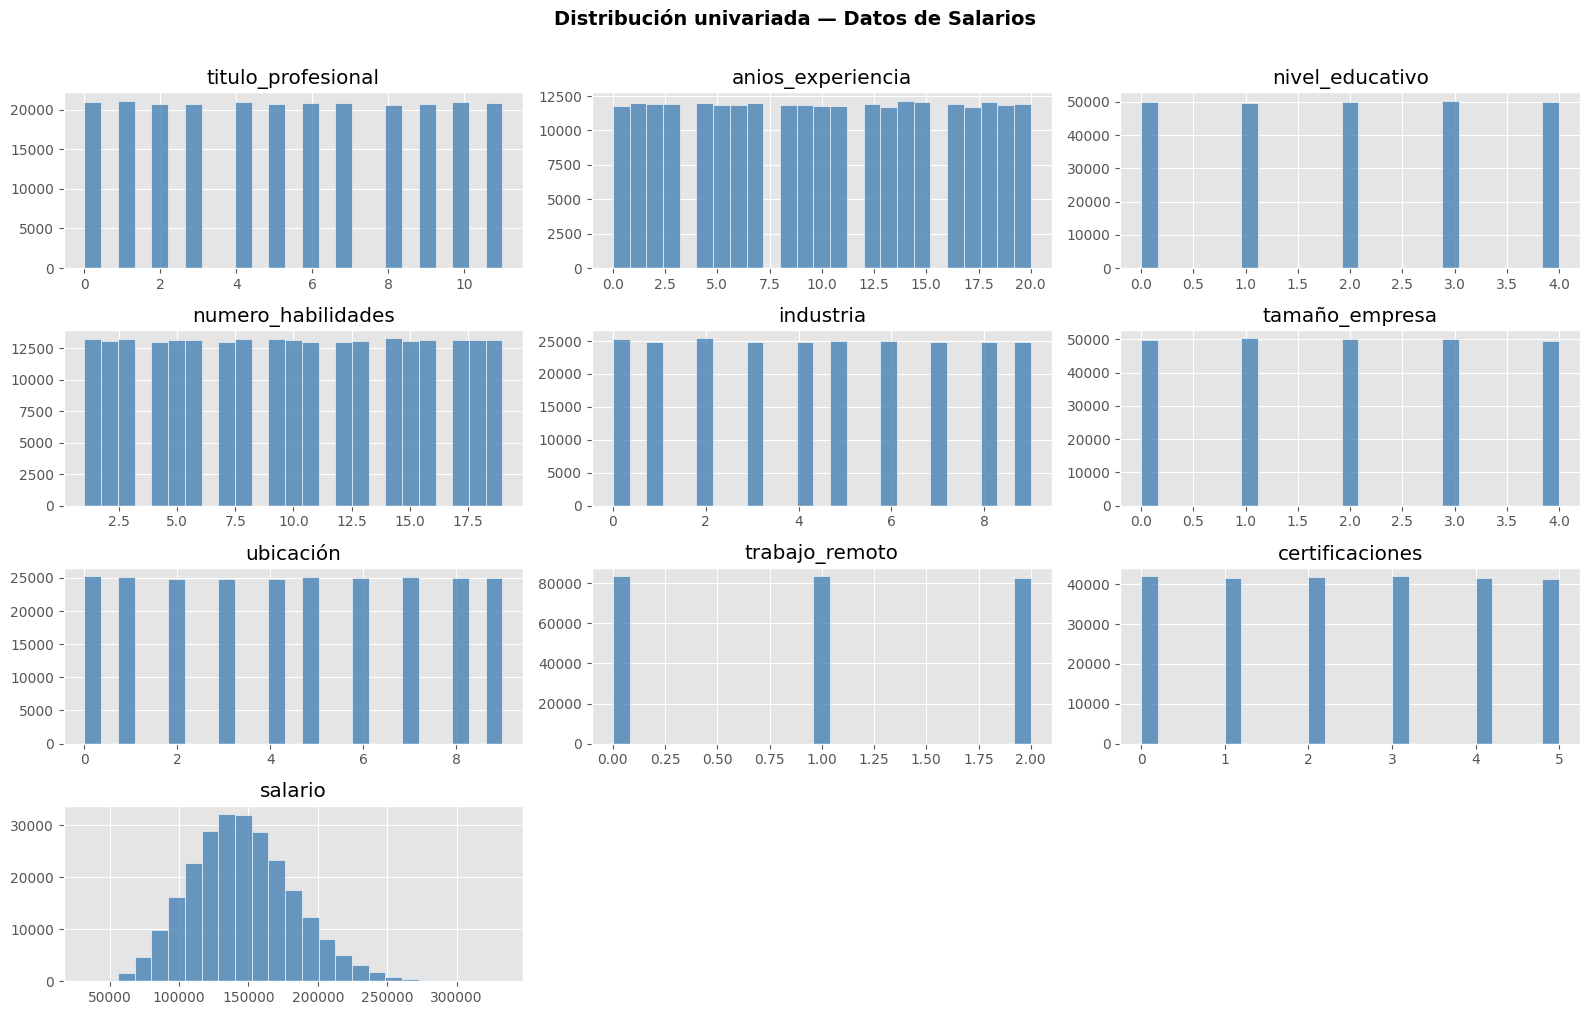

In [ ]:
# Histogramas univariados
fig = plt.figure(figsize=(16, 10))
ax  = fig.gca()
datos.hist(ax=ax, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
fig.suptitle('Distribución univariada — Datos de Salarios',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

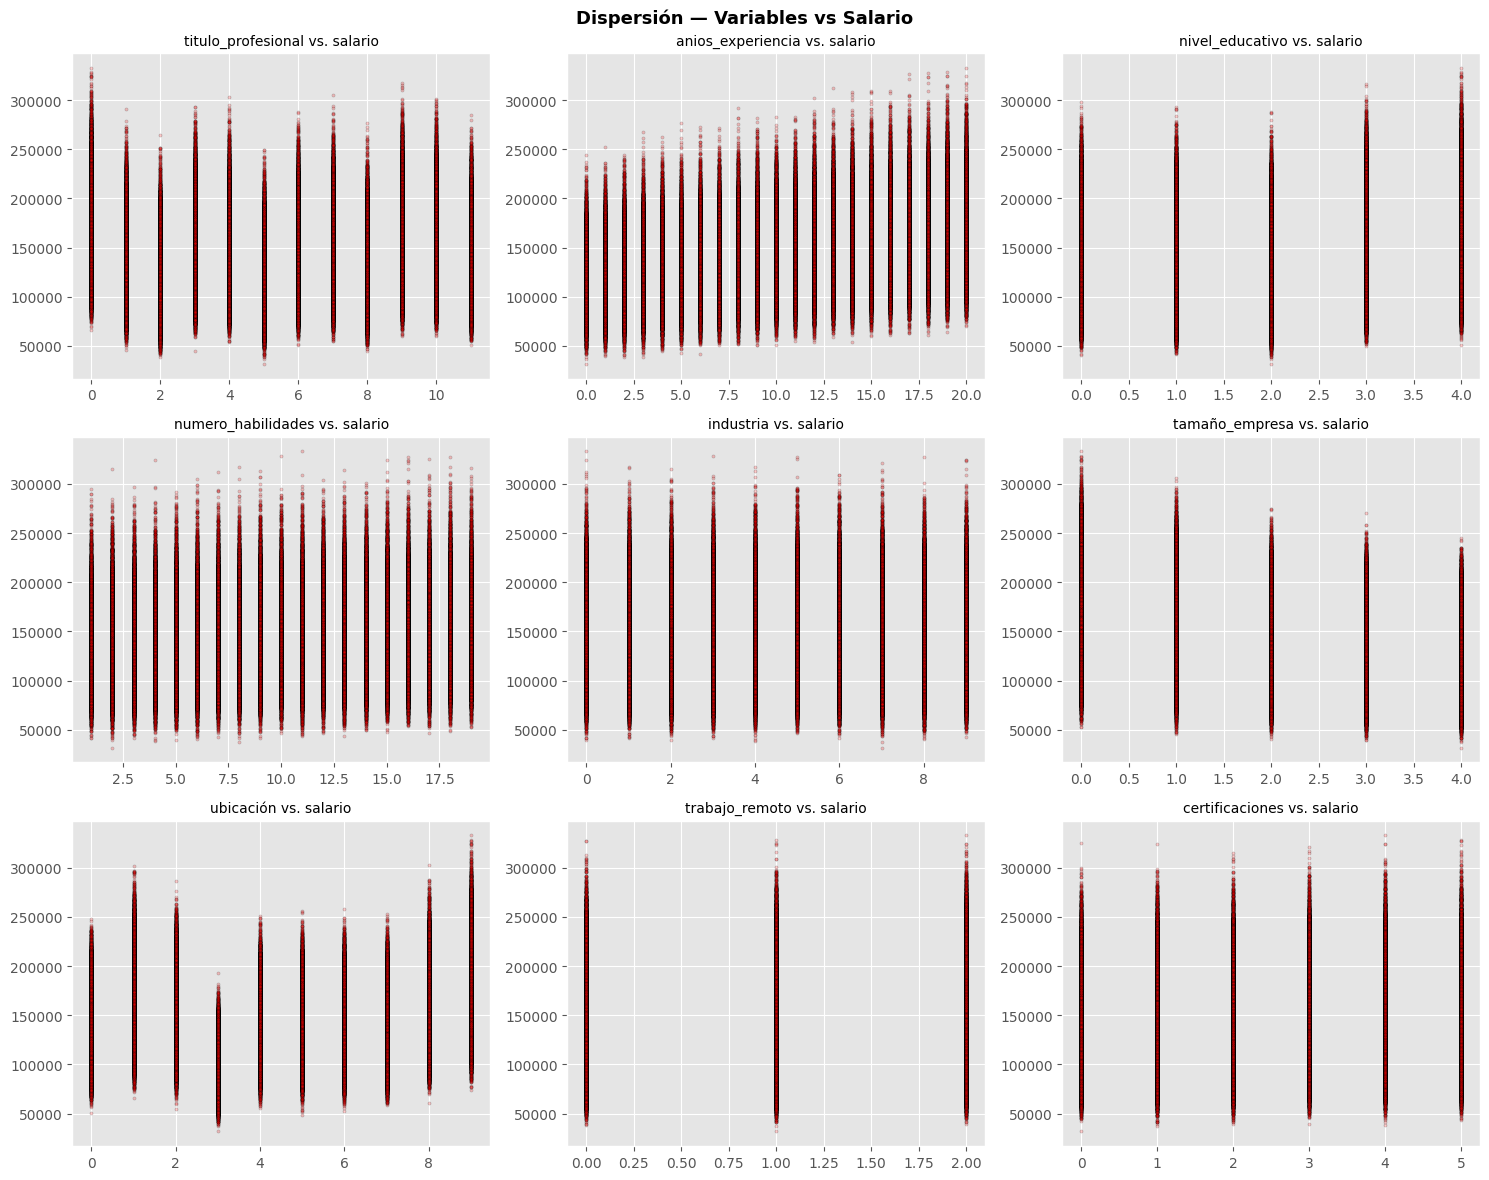

In [ ]:
# Gráficos de dispersión: cada variable vs salario
features = [c for c in datos.columns if c != 'salario']
n = len(features)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, ax = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
ax = ax.ravel()
for i, feat in enumerate(features):
    ax[i].scatter(datos[feat], datos['salario'],
                  edgecolor='k', color='red', alpha=0.20, s=5)
    ax[i].set_title(f'{feat} vs. salario', fontsize=10)
    ax[i].grid(True)

for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

plt.suptitle('Dispersión — Variables vs Salario', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

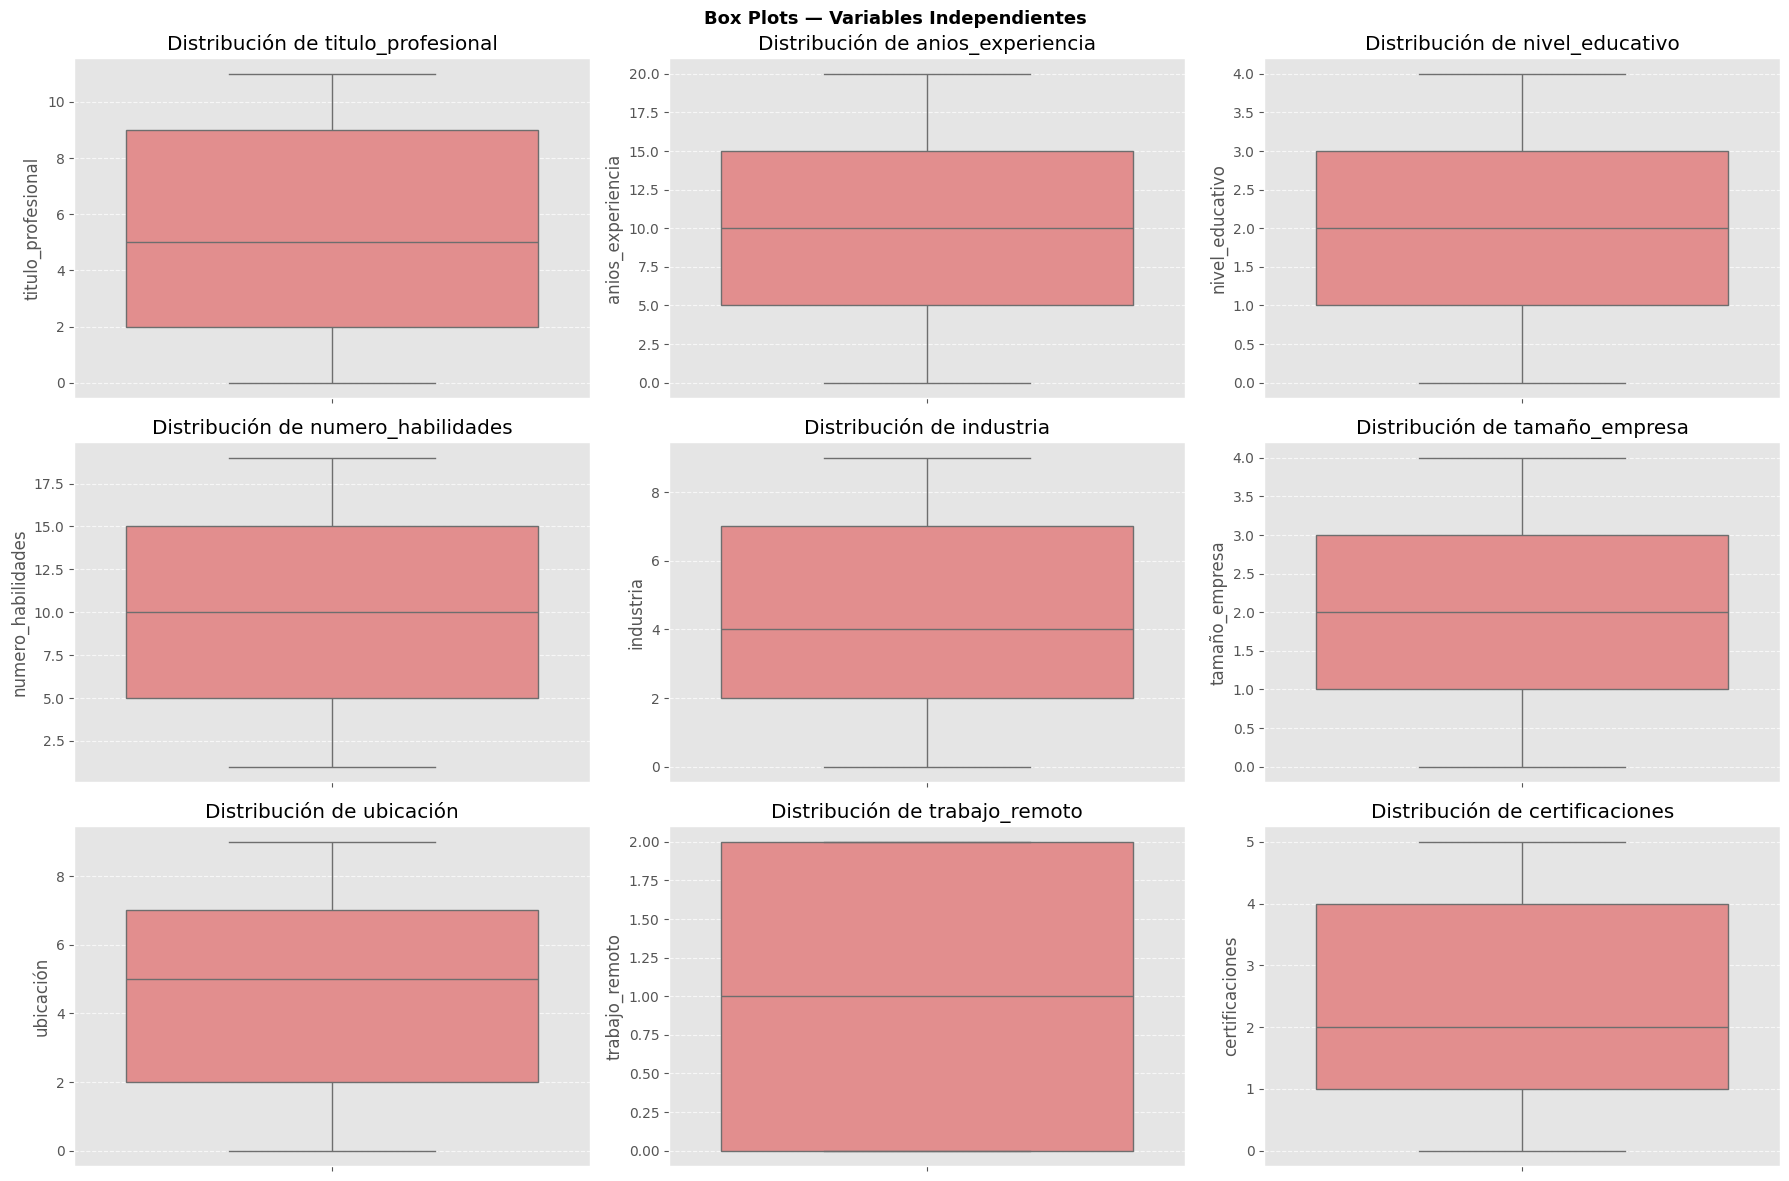

In [ ]:
# Box Plots de variables independientes
independent_vars = [c for c in datos.columns if c != 'salario']
n_cols = 3
n_rows = (len(independent_vars) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(independent_vars):
    sns.boxplot(y=datos[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

for j in range(len(independent_vars), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Box Plots — Variables Independientes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

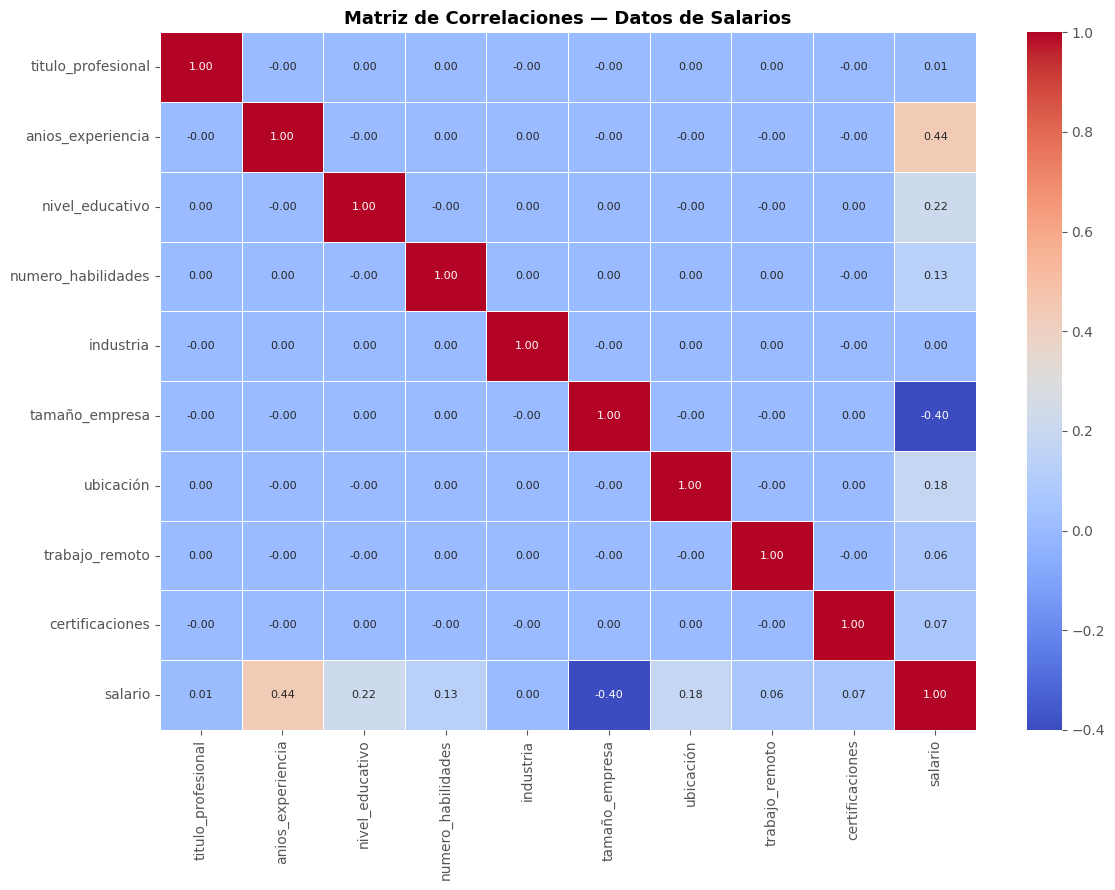

In [ ]:
# Mapa de calor de correlaciones
plt.figure(figsize=(12, 9))
sns.heatmap(
    datos.corr().round(2),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Matriz de Correlaciones — Datos de Salarios',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preparación de Datos — Train / Test Split

In [ ]:
# Dado el tamaño del dataset (250k filas), usamos una muestra de 20,000 para entrenar SVR
# SVR tiene complejidad cuadrática; muestras grandes aumentan el tiempo de entrenamiento significativamente
datos_sample = datos.sample(n=20000, random_state=1234)

X = datos_sample.drop(columns='salario')
Y = datos_sample['salario']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y.values.reshape(-1, 1),
    train_size=0.8,
    random_state=1234,
    shuffle=True
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (16000, 9) | Test: (4000, 9)


In [ ]:
# Estandarización de variables
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print('Escalado aplicado ✔')

Escalado aplicado ✔


## 5. Modelo SVR con Kernel Lineal

In [ ]:
# Búsqueda del mejor C — kernel lineal
print(f"{'C':>4}  {'RMSE':>10}  {'MSE':>12}  {'R2':>7}")
print('─' * 40)

_c_values  = []
_rmse_list = []
_best_c    = 1
_best_rmse = float('inf')

for _c in range(1, 50, 2):
    _svm_tmp  = SVR(kernel='linear', C=_c)
    _svm_tmp.fit(X_train, y_train.ravel())
    _pred_tmp = _svm_tmp.predict(X_test)

    _mse_tmp  = mean_squared_error(y_test, _pred_tmp)
    _rmse_tmp = np.sqrt(_mse_tmp)
    _r2_tmp   = r2_score(y_test, _pred_tmp)

    _c_values.append(_c)
    _rmse_list.append(_rmse_tmp)

    if _rmse_tmp < _best_rmse:
        _best_rmse = _rmse_tmp
        _best_c    = _c

    print(f'{_c:>4}  {_rmse_tmp:>10.4f}  {_mse_tmp:>12.4f}  {_r2_tmp:>7.4f}')

print(f'\n  ✔ Mejor C encontrado : {_best_c}  (RMSE: {_best_rmse:.4f})\n')

   C        RMSE           MSE       R2
────────────────────────────────────────
   1  33569.8424  1126934317.3981   0.2227
   3  29936.5333  896196027.0466   0.3818
   5  28901.6659  835306293.5042   0.4238
   7  28453.6031  809607529.8660   0.4416
   9  28213.5883  796006567.2642   0.4509
  11  28066.3964  787722604.8261   0.4567
  13  27972.1006  782438412.3609   0.4603
  15  27921.0585  779585505.4252   0.4623
  17  27859.3928  776145765.1874   0.4646
  19  27824.3659  774195337.1831   0.4660
  21  27800.7929  772884084.3957   0.4669
  23  27774.6606  771431769.8131   0.4679
  25  27749.8155  770052262.5283   0.4688
  27  27732.6774  769101395.7294   0.4695
  29  27720.5936  768431311.5531   0.4700
  31  27709.0551  767791732.2396   0.4704
  33  27697.9503  767176449.8794   0.4708
  35  27691.8112  766836406.0358   0.4711
  37  27684.4572  766429168.8150   0.4713
  39  27679.7807  766170258.4961   0.4715
  41  27673.5281  765824159.8529   0.4718
  43  27667.6767  765500331.8418   0

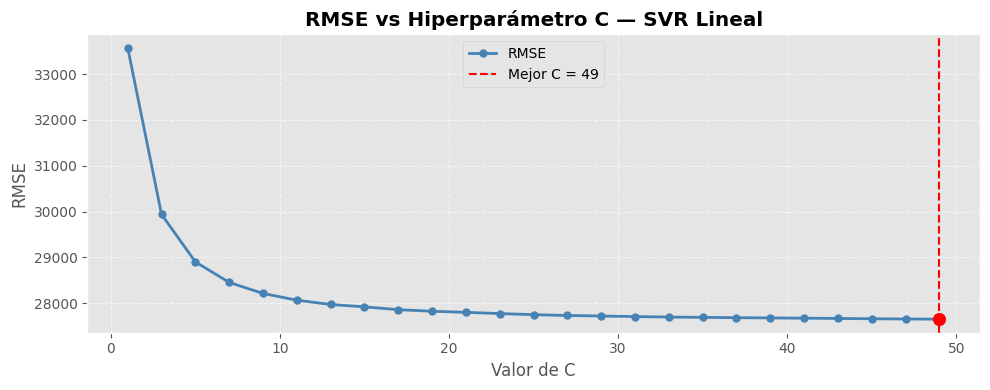

In [ ]:
# Curva RMSE vs C
plt.figure(figsize=(10, 4))
plt.plot(_c_values, _rmse_list, marker='o', color='steelblue',
         linewidth=2, markersize=5, label='RMSE')
plt.axvline(_best_c, color='red', linestyle='--', label=f'Mejor C = {_best_c}')
plt.scatter([_best_c], [_best_rmse], color='red', zorder=5, s=80)
plt.xlabel('Valor de C')
plt.ylabel('RMSE')
plt.title('RMSE vs Hiperparámetro C — SVR Lineal', fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Entrenamiento del modelo final lineal
svmlinear = SVR(kernel='linear', C=_best_c)
svmlinear.fit(X_train, y_train.ravel())
print(f"Modelo entrenado: SVR(kernel='linear', C={_best_c}) ✔")

Modelo entrenado: SVR(kernel='linear', C=49) ✔


In [ ]:
# Predicción
svmlinearpred = svmlinear.predict(X_test)

# Métricas
_mse_final  = mean_squared_error(y_test, svmlinearpred)
_rmse_final = np.sqrt(_mse_final)
_mae_final  = mean_absolute_error(y_test, svmlinearpred)
_r2_final   = r2_score(y_test, svmlinearpred)

print('─' * 42)
print('  Métricas Finales — SVR Lineal')
print('─' * 42)
print(f'  MAE  : {_mae_final:.4f}')
print(f'  MSE  : {_mse_final:.4f}')
print(f'  RMSE : {_rmse_final:.4f}')
print(f'  R²   : {_r2_final:.4f}')
print('─' * 42)

──────────────────────────────────────────
  Métricas Finales — SVR Lineal
──────────────────────────────────────────
  MAE  : 21619.4741
  MSE  : 764647120.7537
  RMSE : 27652.2534
  R²   : 0.4726
──────────────────────────────────────────


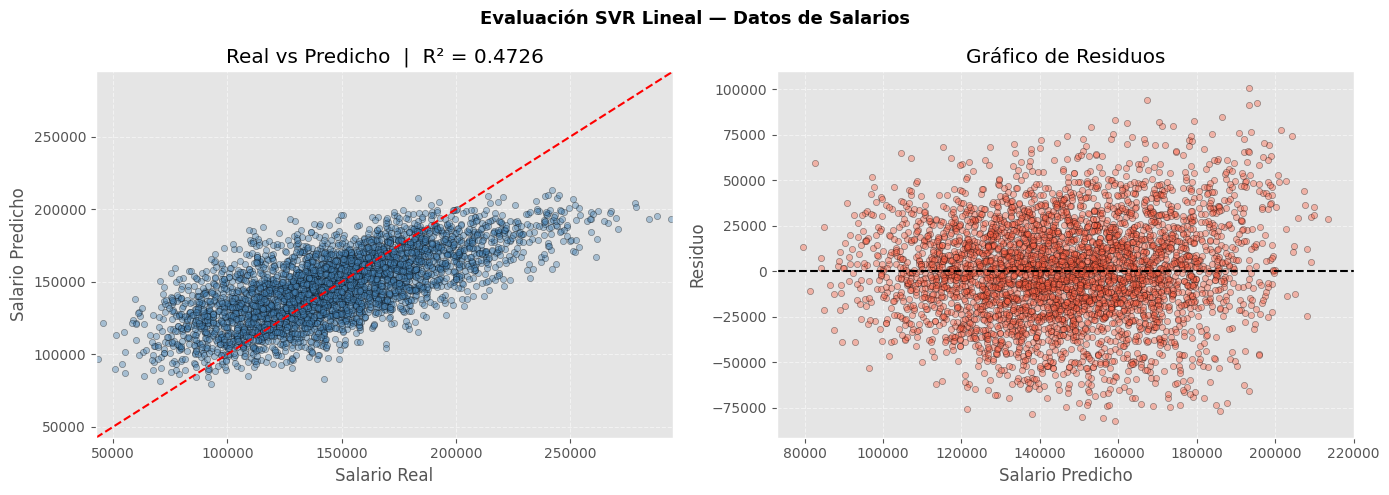

In [ ]:
# Gráfico Real vs Predicho + Residuos — SVR Lineal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Real vs Predicho
axes[0].scatter(y_test.flatten(), svmlinearpred,
                color='steelblue', edgecolor='k', alpha=0.4, s=20)
_lim = [min(y_test.min(), svmlinearpred.min()) - 1000,
        max(y_test.max(), svmlinearpred.max()) + 1000]
axes[0].plot(_lim, _lim, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlim(_lim); axes[0].set_ylim(_lim)
axes[0].set_xlabel('Salario Real')
axes[0].set_ylabel('Salario Predicho')
axes[0].set_title(f'Real vs Predicho  |  R² = {_r2_final:.4f}')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Residuos
_residuos = y_test.flatten() - svmlinearpred
axes[1].scatter(svmlinearpred, _residuos,
                color='tomato', edgecolor='k', alpha=0.4, s=20)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Salario Predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Gráfico de Residuos')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Evaluación SVR Lineal — Datos de Salarios',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Modelo SVR con Kernel RBF (Gaussiano)

In [ ]:
# Búsqueda del mejor C — kernel RBF
print(f"{'C':>4}  {'RMSE':>10}  {'MSE':>12}")
print('─' * 32)

_c_rbf   = []
_rmse_rbf = []
_best_c_rbf    = 1
_best_rmse_rbf = float('inf')

for _c in range(1, 50, 2):
    _svm_tmp = SVR(kernel='rbf', C=_c, gamma='scale')
    _svm_tmp.fit(X_train, y_train.ravel())
    _pred_tmp = _svm_tmp.predict(X_test)

    _mse_tmp  = mean_squared_error(y_test, _pred_tmp)
    _rmse_tmp = np.sqrt(_mse_tmp)

    _c_rbf.append(_c)
    _rmse_rbf.append(_rmse_tmp)

    if _rmse_tmp < _best_rmse_rbf:
        _best_rmse_rbf = _rmse_tmp
        _best_c_rbf    = _c

    print(f'{_c:>4}  {_rmse_tmp:>10.4f}  {_mse_tmp:>12.4f}')

print(f'\n  ✔ Mejor C (RBF): {_best_c_rbf}  (RMSE: {_best_rmse_rbf:.4f})\n')

   C        RMSE           MSE
────────────────────────────────
   1  37994.4956  1443581698.8052
   3  37573.3051  1411753256.9373
   5  37151.6515  1380245207.4254
   7  36753.1994  1350797662.9595
   9  36362.7553  1322249974.5570
  11  35994.7905  1295624940.9398
  13  35644.3804  1270521852.4903
  15  35303.1553  1246312774.5976
  17  34981.9336  1223735679.7802
  19  34673.7428  1202268436.8427
  21  34376.0162  1181710490.9807
  23  34097.5685  1162644179.9186
  25  33826.0372  1144200793.1912
  27  33542.6709  1125110774.0420
  29  33296.2956  1108643301.4203
  31  33040.3808  1091666765.4881
  33  32802.7541  1076020676.4037
  35  32579.5565  1061427504.5819
  37  32356.0014  1046910828.7068
  39  32152.1364  1033759872.9290
  41  31962.6613  1021611715.8576
  43  31781.4530  1010060753.1701
  45  31620.1932  999836620.7335
  47  31442.7704  988647809.9091
  49  31283.2820  978643730.9232

  ✔ Mejor C (RBF): 49  (RMSE: 31283.2820)



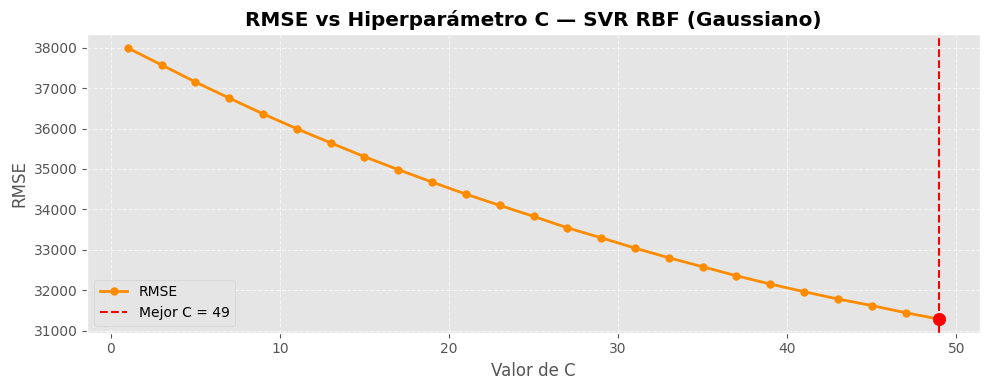

In [ ]:
# Curva RMSE vs C — RBF
plt.figure(figsize=(10, 4))
plt.plot(_c_rbf, _rmse_rbf, marker='o', color='darkorange',
         linewidth=2, markersize=5, label='RMSE')
plt.axvline(_best_c_rbf, color='red', linestyle='--', label=f'Mejor C = {_best_c_rbf}')
plt.scatter([_best_c_rbf], [_best_rmse_rbf], color='red', zorder=5, s=80)
plt.xlabel('Valor de C')
plt.ylabel('RMSE')
plt.title('RMSE vs Hiperparámetro C — SVR RBF (Gaussiano)', fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Modelo RBF final
svmrbf = SVR(kernel='rbf', C=_best_c_rbf, gamma='scale', epsilon=0.1)
svmrbf.fit(X_train, y_train.ravel())
svmrbfpred = svmrbf.predict(X_test)

mse_rbf  = mean_squared_error(y_test, svmrbfpred)
rmse_rbf = np.sqrt(mse_rbf)
mae_rbf  = mean_absolute_error(y_test, svmrbfpred)
r2_rbf   = r2_score(y_test, svmrbfpred)

print('─' * 42)
print('  Métricas Finales — SVR RBF (Gaussiano)')
print('─' * 42)
print(f'  MAE  : {mae_rbf:.4f}')
print(f'  MSE  : {mse_rbf:.4f}')
print(f'  RMSE : {rmse_rbf:.4f}')
print(f'  R²   : {r2_rbf:.4f}')
print('─' * 42)

──────────────────────────────────────────
  Métricas Finales — SVR RBF (Gaussiano)
──────────────────────────────────────────
  MAE  : 24413.1202
  MSE  : 978643730.9232
  RMSE : 31283.2820
  R²   : 0.3250
──────────────────────────────────────────


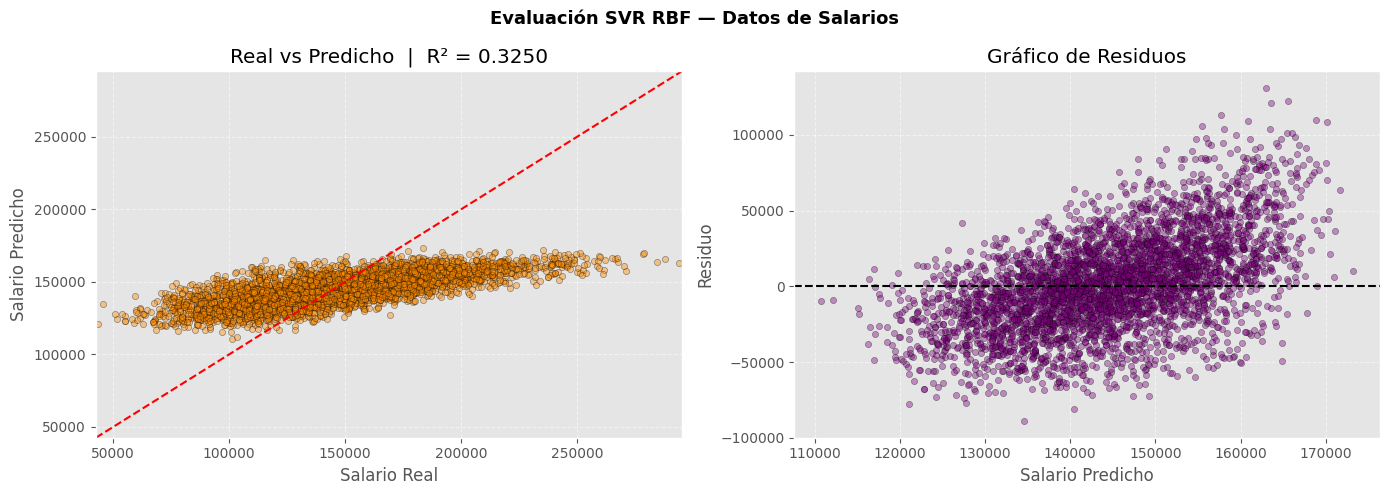

In [ ]:
# Gráfico Real vs Predicho + Residuos — SVR RBF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test.flatten(), svmrbfpred,
                color='darkorange', edgecolor='k', alpha=0.4, s=20)
_lim2 = [min(y_test.min(), svmrbfpred.min()) - 1000,
          max(y_test.max(), svmrbfpred.max()) + 1000]
axes[0].plot(_lim2, _lim2, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlim(_lim2); axes[0].set_ylim(_lim2)
axes[0].set_xlabel('Salario Real')
axes[0].set_ylabel('Salario Predicho')
axes[0].set_title(f'Real vs Predicho  |  R² = {r2_rbf:.4f}')
axes[0].grid(True, linestyle='--', alpha=0.5)

_res_rbf = y_test.flatten() - svmrbfpred
axes[1].scatter(svmrbfpred, _res_rbf,
                color='purple', edgecolor='k', alpha=0.4, s=20)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Salario Predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Gráfico de Residuos')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Evaluación SVR RBF — Datos de Salarios',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Modelo SVR con Kernel Sigmoidal

In [ ]:
# Probando valores de C — kernel sigmoidal
print('C    RMSE        MSE')

_best_c_sig    = 1
_best_rmse_sig = float('inf')

for i in range(1, 15, 1):
    svmsigmoid = SVR(kernel='sigmoid', C=i, gamma='scale')
    svmsigmoid.fit(X_train, y_train.ravel())
    svmsigmoidpred = svmsigmoid.predict(X_test)

    mse  = mean_squared_error(y_test, svmsigmoidpred)
    rmse = np.sqrt(mse)
    print(f'{i:<4} {rmse:.4f}      {mse:.4f}')

    if rmse < _best_rmse_sig:
        _best_rmse_sig = rmse
        _best_c_sig    = i

print(f'\n  ✔ Mejor C (Sigmoidal): {_best_c_sig}  (RMSE: {_best_rmse_sig:.4f})')

C    RMSE        MSE
1    37613.4598      1414772360.3271
2    37040.6014      1372006150.9915
3    36488.5159      1331411793.0697
4    35980.1261      1294569471.3554
5    35505.4281      1260635427.6574
6    35060.6174      1229246891.0561
7    34639.3861      1199887067.3877
8    34247.9441      1172921677.9376
9    33892.6221      1148709831.7719
10   33538.4287      1124826198.5016
11   33205.8907      1102631179.8395
12   32906.6862      1082849996.1925
13   32625.5345      1064425501.2520
14   32360.8815      1047226649.3525

  ✔ Mejor C (Sigmoidal): 14  (RMSE: 32360.8815)


In [ ]:
# Modelo sigmoidal final
svmsigmoid = SVR(kernel='sigmoid', C=_best_c_sig, gamma='scale')
svmsigmoid.fit(X_train, y_train.ravel())
svmsigmoidpred = svmsigmoid.predict(X_test)

mse_sig  = mean_squared_error(y_test, svmsigmoidpred)
rmse_sig = np.sqrt(mse_sig)
mae_sig  = mean_absolute_error(y_test, svmsigmoidpred)
r2_sig   = r2_score(y_test, svmsigmoidpred)

print('─' * 42)
print('  Métricas Finales — SVR Sigmoidal')
print('─' * 42)
print(f'  MAE  : {mae_sig:.4f}')
print(f'  MSE  : {mse_sig:.4f}')
print(f'  RMSE : {rmse_sig:.4f}')
print(f'  R²   : {r2_sig:.4f}')
print('─' * 42)

## 8. Comparación de Modelos

In [ ]:
# Tabla comparativa de los 3 modelos
comparacion = pd.DataFrame({
    'Kernel'  : ['Lineal', 'RBF (Gaussiano)', 'Sigmoidal'],
    'Mejor C' : [_best_c, _best_c_rbf, _best_c_sig],
    'MAE'     : [_mae_final, mae_rbf, mae_sig],
    'RMSE'    : [_rmse_final, rmse_rbf, rmse_sig],
    'R²'      : [_r2_final, r2_rbf, r2_sig]
})

print(comparacion.to_string(index=False))
mejor = comparacion.loc[comparacion['RMSE'].idxmin(), 'Kernel']
print(f'\n  ✔ Mejor modelo: {mejor}')

         Kernel  Mejor C          MAE         RMSE       R²
         Lineal       49 21619.474085 27652.253448 0.472571
RBF (Gaussiano)       49 24413.120204 31283.281972 0.324963
      Sigmoidal       14 25407.550812 32360.881467 0.277657

  ✔ Mejor modelo: Lineal


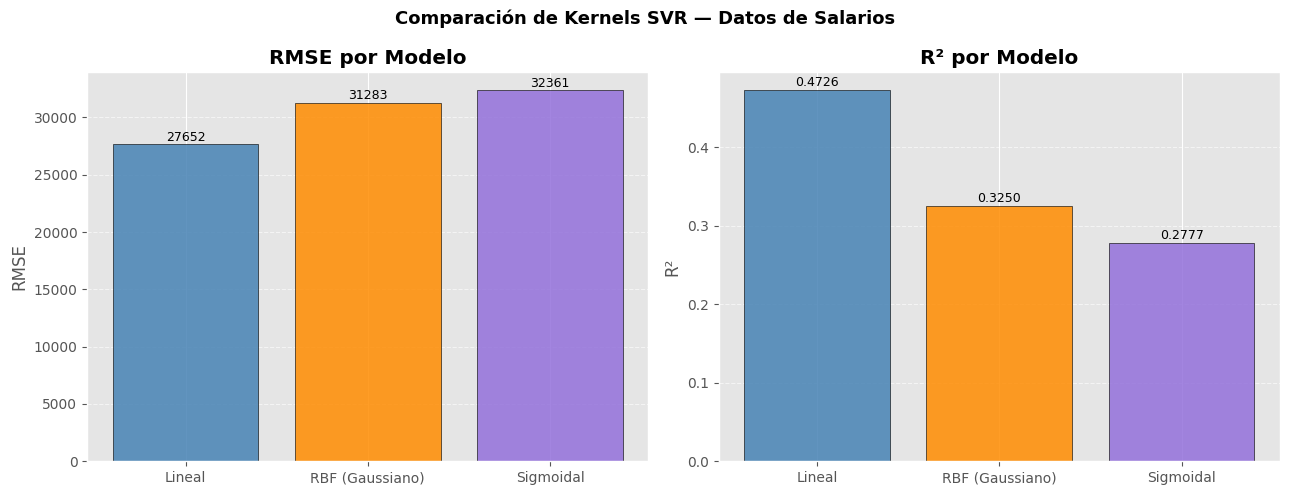

In [ ]:
# Gráfico comparativo de RMSE
colores = ['steelblue', 'darkorange', 'mediumpurple']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(comparacion['Kernel'], comparacion['RMSE'],
                    color=colores, edgecolor='k', alpha=0.85)
axes[0].set_title('RMSE por Modelo', fontweight='bold')
axes[0].set_ylabel('RMSE')
for bar, val in zip(bars, comparacion['RMSE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

bars2 = axes[1].bar(comparacion['Kernel'], comparacion['R²'],
                     color=colores, edgecolor='k', alpha=0.85)
axes[1].set_title('R² por Modelo', fontweight='bold')
axes[1].set_ylabel('R²')
for bar, val in zip(bars2, comparacion['R²']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Comparación de Kernels SVR — Datos de Salarios',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Mejor Modelo — Predicción de Nuevos Datos

In [ ]:
# Predicción con el mejor modelo sobre nuevos datos de ejemplo
# Las columnas categóricas ya están codificadas numéricamente
# Los valores numéricos corresponden a los índices que asignó LabelEncoder

feature_columns = X.columns.tolist()

new_data = pd.DataFrame({
    'titulo_profesional' : [2, 5, 8],        # índice según LabelEncoder
    'anios_experiencia'  : [5, 10, 15],
    'nivel_educativo'    : [0, 2, 4],         # índice: Bachelor, Diploma, PhD...
    'numero_habilidades' : [8, 12, 15],
    'industria'          : [1, 3, 7],
    'tamaño_empresa'     : [2, 3, 4],
    'ubicación'          : [0, 5, 9],
    'trabajo_remoto'     : [0, 1, 2],
    'certificaciones'    : [1, 2, 4]
})

# Asegurar mismo orden de columnas que el training
new_data_aligned = new_data[feature_columns]
new_data_scaled  = scaler.transform(new_data_aligned)

# Usar el mejor modelo RBF para la predicción
new_predictions = svmrbf.predict(new_data_scaled)

print('Predicciones de salario para los nuevos perfiles:')
print('─' * 40)
for i, pred in enumerate(new_predictions):
    print(f'  Perfil {i+1}: ${pred:,.2f}')